In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("13_carweight_vs_fuel_consumption.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
  car_weight_kg exercise_hours_per_week diet_score gender_male  \
0        1197.0                    0.56       1.64           1   
1        1771.0                    7.25       1.71           1   
2        1844.0                    1.96       1.43           1   
3        2268.0                     6.5       6.68           0   
4           0.0                    8.12        6.0           0   

  fuel_l_per_100km  
0              5.9  
1              8.7  
2             10.2  
3             11.1  
4             10.0  

Shape of dataset:
(308, 5)

Columns:
Index(['car_weight_kg', 'exercise_hours_per_week', 'diet_score', 'gender_male',
       'fuel_l_per_100km'],
      dtype='object')

Data types:
car_weight_kg              object
exercise_hours_per_week    object
diet_score                 object
gender_male                object
fuel_l_per_100km           object
dtype: object

Missing values:
car_weight_kg              9
exercise_hours_per_week    5
diet_score             

In [3]:
# Convert required columns to numeric

df['car_weight_kg'] = pd.to_numeric(
    df['car_weight_kg'], errors='coerce'
)

df['fuel_l_per_100km'] = pd.to_numeric(
    df['fuel_l_per_100km'], errors='coerce'
)


# Remove missing values

df = df.dropna(
    subset=[
        'car_weight_kg',
        'fuel_l_per_100km'
    ]
)


# Create binary target using median fuel consumption

median_fuel = df['fuel_l_per_100km'].median()

df['fuel_consumption_class'] = (
    df['fuel_l_per_100km'] >= median_fuel
).astype(int)


print("Median Fuel Consumption:", median_fuel)

print("\nBinary Target:")
print(df['fuel_consumption_class'].value_counts())

print("\nDataset:")
print(
    df[
        [
            'car_weight_kg',
            'fuel_l_per_100km',
            'fuel_consumption_class'
        ]
    ].head()
)

Median Fuel Consumption: 8.8

Binary Target:
fuel_consumption_class
1    149
0    140
Name: count, dtype: int64

Dataset:
   car_weight_kg  fuel_l_per_100km  fuel_consumption_class
0         1197.0               5.9                       0
1         1771.0               8.7                       0
2         1844.0              10.2                       1
3         2268.0              11.1                       1
4            0.0              10.0                       1


In [4]:
from sklearn.model_selection import train_test_split

X = df[['car_weight_kg']]
y = df['fuel_consumption_class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (231, 1)
Testing data: (58, 1)


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 1.2339255411251775e-06
Intercept: 0.4938328463635101


In [6]:
# Convert regression predictions into 0 and 1

y_pred_class = (y_pred >= 0.5).astype(int)

print("Predicted values:")
print(y_pred)

print("\nPredicted classes:")
print(y_pred_class)

Predicted values:
[0.49559736 0.49593546 0.49637967 0.49556281 0.49527777 0.49574173
 0.49603294 0.49675848 0.49497299 0.49652651 0.49558749 0.49649813
 0.49557638 0.49665483 0.49544065 0.49691519 0.49602183 0.4953987
 0.495126   0.49557145 0.49566029 0.49660548 0.49521978 0.49627602
 0.49650306 0.49555417 0.49687447 0.49619335 0.49502112 0.49498286
 0.49630317 0.49536045 0.49565659 0.49497176 0.49506924 0.49518646
 0.49515932 0.49568127 0.4965117  0.49675602 0.49661658 0.49676219
 0.49621432 0.49625751 0.49558008 0.49536662 0.49642532 0.49627355
 0.49681278 0.49677329 0.49523582 0.49663016 0.49545916 0.4965117
 0.49682018 0.49607982 0.49659931 0.4965882 ]

Predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.41379310344827586
Accuracy percentage: 41.37931034482759 %


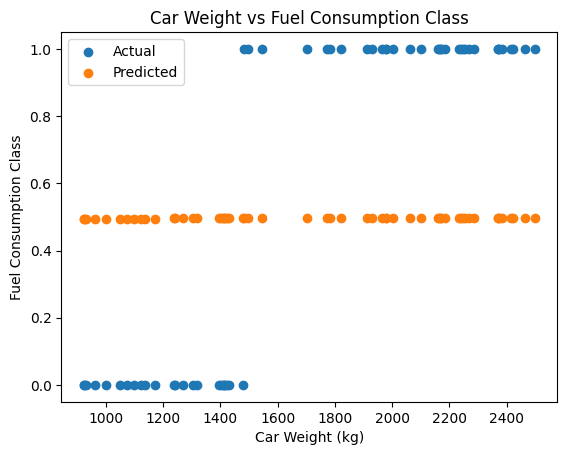

In [8]:
import matplotlib.pyplot as plt

plt.scatter(
    X_test,
    y_test,
    label='Actual'
)

plt.scatter(
    X_test,
    y_pred,
    label='Predicted'
)

plt.xlabel("Car Weight (kg)")
plt.ylabel("Fuel Consumption Class")
plt.title("Car Weight vs Fuel Consumption Class")

plt.legend()
plt.show()

In [10]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    predicted_class = (y_pred >= threshold).astype(int)

    accuracy = accuracy_score(
        y_test,
        predicted_class
    )

    print(
        "Threshold:",
        threshold,
        "Accuracy:",
        accuracy
    )

Threshold: 0.3 Accuracy: 0.5862068965517241
Threshold: 0.4 Accuracy: 0.5862068965517241
Threshold: 0.5 Accuracy: 0.41379310344827586
Threshold: 0.6 Accuracy: 0.41379310344827586
Threshold: 0.7 Accuracy: 0.41379310344827586


In [ ]:
new_car = [[1500]]

prediction = model.predict(new_car)

print("Regression prediction:", prediction[0])

if prediction[0] >= 0.5:
    print("Fuel Consumption Class: 1")
else:
    print("Fuel Consumption Class: 0")